In [1]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
import matplotlib.pyplot as plt
import time


import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

## Definizione MESH

In [2]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

In [3]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [4]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001   # mesh_size è il parametro h — cioè la dimensione caratteristica degli elementi della mesh. 
# Indica la lunghezza massima (o tipica) dello spigolo di un triangolo. Errore scala con tale taglia: ‖u − u_h‖ ≤ C · h^k

In [5]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

## Boundary condition e FEM

In [6]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [7]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [8]:
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

In [9]:
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


## Definizione operatori lineari e che non dipendono da parametri)

In [10]:
def nu_term(x, y, z):  
    return 1.0
def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])

A_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data, nu_term)
J_A_x = other_ut.make_np_sparse(A_op.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_op.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])

B_x_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data, b_x_term)
B_y_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data, b_y_term)

J_B_x  = other_ut.make_np_sparse(B_x_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0])
J_B_y  = other_ut.make_np_sparse(B_y_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs], True)

### Funzione per calcolo FOM

In [11]:
def find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs):

    # inizializzazione
    u_x_numeric = np.zeros(speed_n_dofs)
    u_y_numeric = np.zeros(speed_n_dofs)
    p_numeric   = np.zeros(pressure_n_dofs)
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong   = np.zeros(pressure_n_strongs)
    
    last_sol_u = np.zeros(tot_dofs)
    
    residual_norm, solution_norm = 1.0, 1.0
    
    newton_tol, max_iterations, num_iteration = 1.0e-6, 100, 1

    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_x_numeric, u_y_numeric, u_x_strong, u_y_strong)
 
        J_C = other_ut.make_np_sparse(c_op.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])
 
        J_f = f_S - f_C - J_S @ u_k
        du  = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du        
 
        u_x_numeric = u_k[:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2*speed_n_dofs]
        p_numeric   = u_k[2*speed_n_dofs:]
 
        du_x = du[:speed_n_dofs]
        du_y = du[speed_n_dofs:2*speed_n_dofs]
        dp   = du[2*speed_n_dofs:]


        ## NORME ERRORI E RESIDUI

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)
           
        solution_norm = np.sqrt(np.linalg.norm(u_x_numeric)**2 + 
                               np.linalg.norm(u_y_numeric)**2 +
                               np.linalg.norm(p_numeric)**2) 
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                               du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                               dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);  # norma residui
    
        num_iteration += 1

        last_sol_u = u_k.copy()
 
    # Stampa quale criterio ha fermato Newton
    if residual_norm <= newton_tol * solution_norm:
        flag = True
    else:
        flag = False

    
    
    return last_sol_u, flag, num_iteration

### Definizione domini e parametri per POD e supremizer

In [12]:

snapshot_num = 100  # larghezza training set iniziale
tol = 1. - 1e-7   # qnt massima da spiegare con gli snapshot presi come base dello spazio ridotto
N_max = 30    # numero massimo di snapshots nella base dello spazio ridotto

mu0_range = [0.1, 10.0]   # dominio fornito da prof
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))


In [13]:
# Per il supremizer
X_1 = other_ut.make_np_sparse(A_op.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [0, 0])
X_2 = other_ut.make_np_sparse(A_op.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [speed_n_dofs, speed_n_dofs])
B_1 = other_ut.make_np_sparse(B_x_op.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(B_y_op.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, speed_n_dofs])

### POD

In [14]:
snapshot_matrix_u = []  # sia u_x che u_y
snapshot_matrix_s = [] ### supremizer snapshot
snapshot_matrix_p = []

print("Performing training...")

it = 0
for mu in training_set:

  if it % 10 == 0:
      print("\tIterations", 2 * it, " /", training_set.size)
  it = it + 1

  mu_0 = mu[0]
  mu_1 = mu[1]

  def pressure_strong_function(marker, x, y, z):  # definisco qui perché in generale potrebbe dipendere dai parametri
    return 0.0
    
  p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
  def speed_x_strong_function(marker, x, y, z):
        return 0.0
    
  def speed_y_strong_function(marker, x, y, z):
        return 0.0
    
  u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_x_strong_function)
  u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)
    
 
  def f_x_function(x, y, z):
        return - ((mu_1**3) * np.pi * np.pi * np.cos((mu_1**2)* np.pi * x) - (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) + (+mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y))
  def f_y_function(x, y, z):
        return - (-(mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * y) + (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) + (-mu_1* np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y))
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante
    
  snapshot_solution, flag, num_iter = find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)  
    
  snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
  snapshot_matrix_u.append(np.copy(snapshot_u))
  
  snapshot_p = snapshot_solution[2 * speed_n_dofs:]
  snapshot_matrix_p.append(np.copy(snapshot_p))

  snapshot_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snapshot_p)
  snapshot_matrix_s.append(np.copy(snapshot_s)) 

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)  

print("Training performed")

Performing training...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Training performed


In [15]:
inner_product_u = X_1 + X_2

In [16]:
def eig_analysis(C, N_max=None, tol=1e-9):
    L_e, VM_e = np.linalg.eigh(C)

    # Ordina autovalori e autovettori in ordine decrescente
    idx = np.argsort(L_e)[::-1]
    L_e = L_e[idx]
    VM_e = VM_e[:, idx]

    eigenvalues = []
    eigenvectors = []

    for i in range(len(L_e)):
        eigenvalues.append(L_e[i])
        eigenvectors.append(VM_e[:, i])

    total_energy = sum(eigenvalues)
    retained_energy_vector = np.cumsum(eigenvalues)
    relative_retained_energy = retained_energy_vector / total_energy

    N = np.argmax(relative_retained_energy >= tol) + 1

    if N_max is not None:
        N = min(N, N_max)

    return N, eigenvectors


In [17]:
### covariance matrix

C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)

N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)

print(N_u, N_s, N_p)
reduced_u_dof = N_u + N_s

19 25 25


In [18]:
def create_basis_functions_matrix(N, snapshot_matrix, eigenvectors, inner_product=None):
  
  basis_functions = []
  
  for n in range(N):
    eigenvector =  eigenvectors[n]
    basis = np.transpose(snapshot_matrix)@eigenvector
    if inner_product!= None:
      norm = np.sqrt(np.transpose(basis) @ inner_product @ basis) ## metti inner product
    else:
      norm = np.sqrt(np.transpose(basis) @ basis)
    basis /= norm
    basis_functions.append(np.copy(basis))

  basis_function_matrix = np.transpose(np.array(basis_functions))
  
  return basis_function_matrix

In [19]:
basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

In [20]:
print(basis_functions_u.shape)
print(basis_functions_p.shape)
print(basis_functions_u.shape[0] + basis_functions_p.shape[0])
print(basis_functions_p.shape)

global_basis_function_matrix = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
global_basis_function_matrix[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix[0:basis_functions_u.shape[0], N_u : N_u + N_s] = basis_functions_s
global_basis_function_matrix[basis_functions_u.shape[0]:, N_u + N_s:] = basis_functions_p
print(global_basis_function_matrix.shape)

global_basis_function_matrix_no_sup = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_p))
global_basis_function_matrix_no_sup[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix_no_sup[basis_functions_u.shape[0]:, N_u:] = basis_functions_p

(5932, 19)
(829, 25)
6761
(829, 25)
(6761, 69)


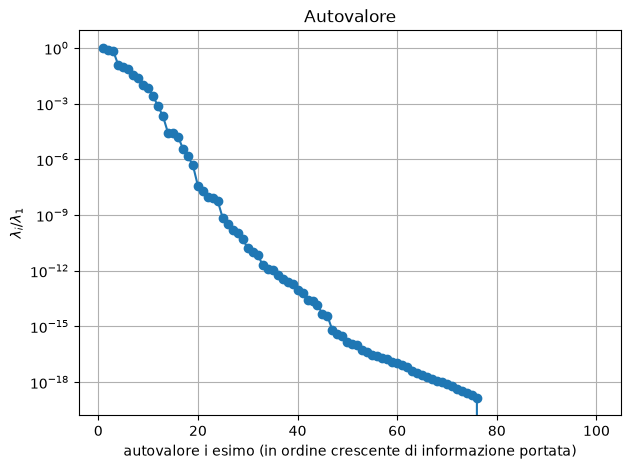

In [21]:
## GRAFICO: valore autovalori (quantità informazione portata)
eigvals = np.linalg.eigvalsh(C_u)
eigvals = np.sort(eigvals)[::-1]

plt.figure(figsize=(7,5))
plt.semilogy(range(1,len(eigvals)+1), eigvals/eigvals[0], '-o')

plt.xlabel("autovalore i esimo (in ordine crescente di informazione portata)")
plt.ylabel(r"$\lambda_i/\lambda_1$")
plt.title("Autovalore")
plt.grid(True)

plt.show()

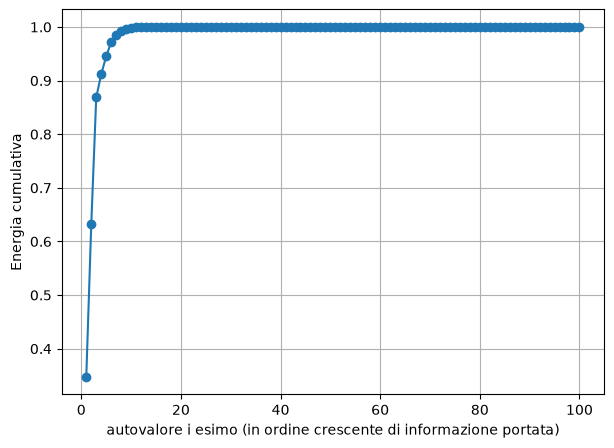

In [22]:
## GRAFICO: energia/informazione cumulata
energy = np.cumsum(eigvals)/np.sum(eigvals)

plt.figure(figsize=(7,5))

plt.plot(range(1,len(energy)+1), energy,'-o')

plt.xlabel("autovalore i esimo (in ordine crescente di informazione portata)")
plt.ylabel("Energia cumulativa")
plt.grid(True)

plt.show()

### Funzione per calcolo ROM

In [23]:
def find_ROM_newton(global_basis_function_matrix, J_S, f_S):
    newton_tol=1e-6
    max_iterations=30
    u_k = reduced_initial_solution.copy()
    residual_norm = 1
    solution_norm = 0
    num_iteration = 0
    full_solution = global_basis_function_matrix @ u_k
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)

    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        u_x_numeric = full_solution[:speed_n_dofs]
        u_y_numeric = full_solution[speed_n_dofs:2*speed_n_dofs]
        p_numeric = full_solution[2*speed_n_dofs:]
        
        # termine convettivo
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_x_numeric, u_y_numeric, u_x_strong, u_y_strong)

        J_C = other_ut.make_np_sparse(c_op.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])
 
        J_f = f_S - f_C - J_S @ full_solution
        J_tot = J_S + J_C

        J_tot_red = global_basis_function_matrix.transpose() @ J_tot @ global_basis_function_matrix 
        J_f_red = global_basis_function_matrix.transpose() @ J_f
        du = np.linalg.solve(J_tot_red, J_f_red)

        u_k = u_k + du        

         ## NORME ERRORI E RESIDUI

        full_solution = global_basis_function_matrix @ u_k
        du_full = global_basis_function_matrix @ du


        u_x_numeric = full_solution[:speed_n_dofs]
        u_y_numeric = full_solution[speed_n_dofs:2*speed_n_dofs]
        p_numeric = full_solution[2*speed_n_dofs:]

        du_x = du_full[:speed_n_dofs]
        du_y = du_full[speed_n_dofs:2*speed_n_dofs]
        dp = du_full[2*speed_n_dofs:]
    

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)

        solution_norm = np.sqrt(np.linalg.norm(u_x_numeric)**2 + 
                               np.linalg.norm(u_y_numeric)**2 +
                               np.linalg.norm(p_numeric)**2) 
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                               du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                               dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);
        num_iteration += 1

    if residual_norm <= newton_tol * solution_norm:
        flag = True
    else:
        flag = False
    
    return full_solution, u_k, flag, num_iteration

In [24]:
def compute_error(fom_solution, rom_solution_FE_basis, inner_product=None, type_err="relative"):
    
    error_function_u = fom_solution - rom_solution_FE_basis
    
    if inner_product == None:
        inner_product_matrix = np.identity(fom_solution.shape[0])
    else:
      inner_product_matrix = inner_product
    
    error_norm_squared_component = np.transpose(error_function_u) @ inner_product_matrix @ error_function_u
    absolute_error = np.sqrt(abs(error_norm_squared_component))
    
    if type_err == "absolute":
      return absolute_error
    else:
      full_solution_norm_squared_component = np.transpose(fom_solution) @  inner_product_matrix @ fom_solution
      relative_error = absolute_error/np.sqrt(abs(full_solution_norm_squared_component))
    
      return relative_error

### Valutare FOM e ROM su parametri mu_0 e mu_1 ulteriori dal training set

In [25]:
num_coppie_par = 100  # larghezza training set iniziale

mu0_range = [0.1, 10.0]   # dominio fornito da prof
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

testing_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(num_coppie_par, P.shape[0]))


#### Esempio soluzione POD + ROM con parametri fissati

In [26]:
print("parametri")
mu = testing_set[0]      # singola coppia di parametri (mu_0, mu_1)
mu_0 = mu[0]
mu_1 = mu[1]
print(mu_0)
print(mu_1)

def pressure_strong_function(marker, x, y, z):  
    return 0.0

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
def speed_x_strong_function(marker, x, y, z):
    return 0.0
def speed_y_strong_function(marker, x, y, z):
    return 0.0

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)


def f_x_function(x, y, z):
    return - ((mu_1**3) * np.pi * np.pi * np.cos((mu_1**2)* np.pi * x) - (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) + (+mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y))
def f_y_function(x, y, z):
    return - (-(mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * y) + (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) + (-mu_1* np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y))


f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])


reduced_initial_solution = np.zeros(global_basis_function_matrix.shape[1])
J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

reduced_solution_FE_basis_full_dim, reduced_solution,flag, num_iterations = find_ROM_newton(global_basis_function_matrix, J_S, f_S)

parametri
3.1867792317416157
2.3926869776309188


In [27]:
reduced_u_x_FE = reduced_solution_FE_basis_full_dim[0:speed_n_dofs]
reduced_u_y_FE = reduced_solution_FE_basis_full_dim[speed_n_dofs:2 * speed_n_dofs]
reduced_p_FE = reduced_solution_FE_basis_full_dim[2 * speed_n_dofs:]

In [28]:
reduced_u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data, reduced_u_x_FE,
                                                                        u_x_strong)
reduced_u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,reduced_u_y_FE,
                                                                                         u_y_strong)
reduced_p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         reduced_p_FE,
                                                                                         p_strong)

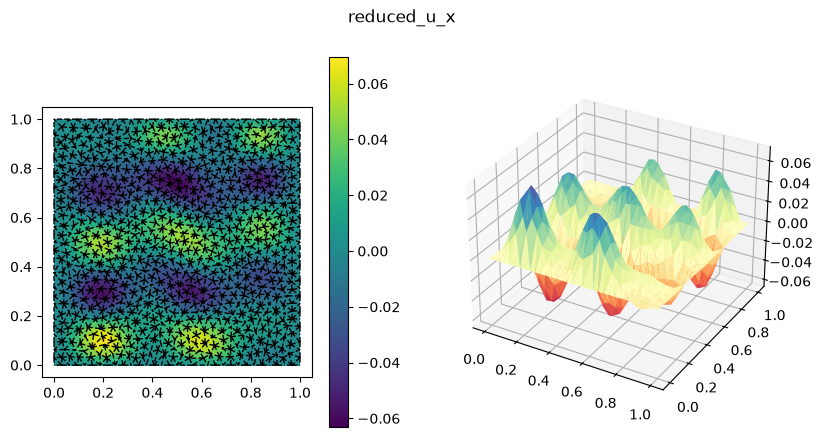

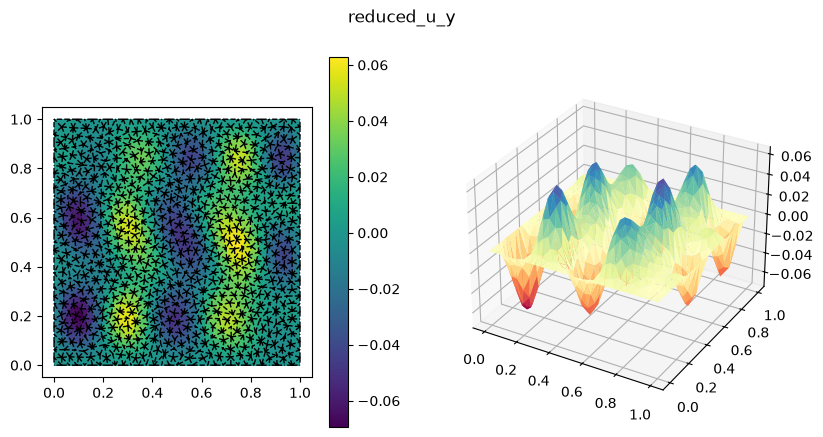

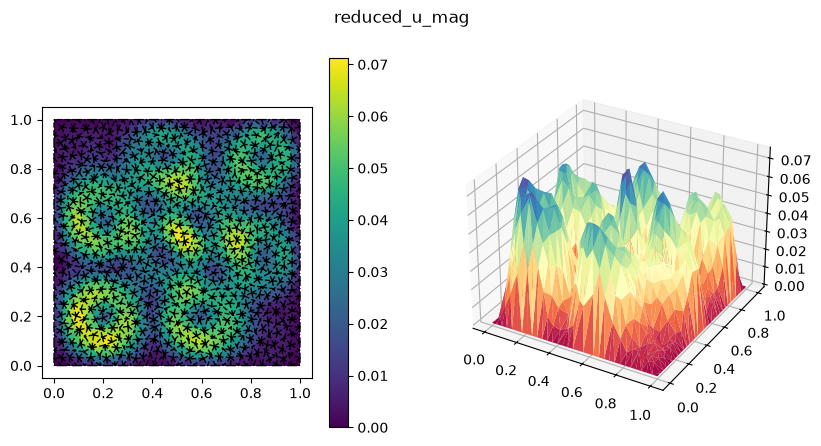

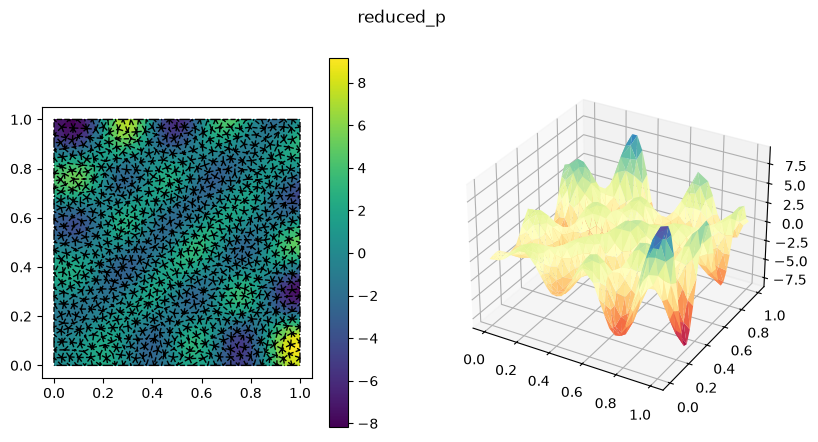

In [29]:
other_ut.plot_solution(mesh, reduced_u_x_on_cell0Ds.numeric_solution, "reduced_u_x") 
other_ut.plot_solution(mesh, reduced_u_y_on_cell0Ds.numeric_solution, "reduced_u_y")
other_ut.plot_solution(mesh, np.sqrt(reduced_u_x_on_cell0Ds.numeric_solution * reduced_u_x_on_cell0Ds.numeric_solution + reduced_u_y_on_cell0Ds.numeric_solution * reduced_u_y_on_cell0Ds.numeric_solution), "reduced_u_mag")
other_ut.plot_solution(mesh, reduced_p_on_cell0Ds.numeric_solution, "reduced_p") 

### Valutare FOM e ROM su parametri mu_0 e mu_1 ulteriori dal training set
Si valutano: accuratezza ROM rispetto a FOM e costi computazionali rispettivi

In [30]:
times_FOM = []
times_ROM = []
conv_flag_FOM = []
conv_flag_ROM = []
num_iter_FOM = []
num_iter_ROM = []
err_u_FOM_ROM  = []
err_p_FOM_ROM = []

for mu in testing_set:
  mu_0 = mu[0]
  mu_1 = mu[1]

  def pressure_strong_function(marker, x, y, z):  # definisco qui perché in generale potrebbe dipendere dai parametri
        return 0.0
    
  p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
  def speed_x_strong_function(marker, x, y, z):
        return 0.0
    
  def speed_y_strong_function(marker, x, y, z):
        return 0.0
    
  u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_x_strong_function)
  u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)


  # FOM starting
  start_FOM = time.perf_counter()
 
  def f_x_function(x, y, z):
        return - ((mu_1**3) * np.pi * np.pi * np.cos((mu_1**2)* np.pi * x) - (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) + (+mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y))
  def f_y_function(x, y, z):
        return - (-(mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * y) + (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) + (-mu_1* np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y))
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante
    
  FOM_solution, type_conv_fom, num_iter_fom = find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)

  elapsed = time.perf_counter() - start_FOM
  times_FOM.append(elapsed)
  conv_flag_FOM.append(type_conv_fom)
  num_iter_FOM.append(num_iter_fom)

    
  # FOM finishing

  # ROM starting
  start_ROM = time.perf_counter()

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y
 
  def f_x_function(x, y, z):
        return - ((mu_1**3) * np.pi * np.pi * np.cos((mu_1**2)* np.pi * x) - (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) + (+mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y))
  def f_y_function(x, y, z):
        return - (-(mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * y) + (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) + (-mu_1* np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y))
    
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante

  reduced_initial_solution = np.zeros(global_basis_function_matrix.shape[1])
  reduced_solution_FE_basis_full_dim, reduced_solution, type_conv_rom, num_iter_rom = find_ROM_newton(global_basis_function_matrix, J_S, f_S)
    
  elapsed = time.perf_counter() - start_ROM
  times_ROM.append(elapsed)
  conv_flag_ROM.append(type_conv_rom)
  num_iter_ROM.append(num_iter_rom)

  # ROM finishing
  err_u_FOM_ROM.append(compute_error(FOM_solution[:2*speed_n_dofs],reduced_solution_FE_basis_full_dim[:2*speed_n_dofs],inner_product=inner_product_u ))
  err_p_FOM_ROM.append(compute_error(FOM_solution[2*speed_n_dofs:], reduced_solution_FE_basis_full_dim[2*speed_n_dofs:]))
  
    

In [31]:
print("\n==================== Risultati ====================\n")

print(f"Tempo medio FOM : {np.mean(times_FOM):.6f} s")
print(f"Tempo medio ROM : {np.mean(times_ROM):.6f} s")

print()

print(f"Errore medio velocità   (FOM vs ROM): {np.mean(err_u_FOM_ROM):.3e}")
print(f"Errore medio pressione  (FOM vs ROM): {np.mean(err_p_FOM_ROM):.3e}")

print()

print(f"Iterazioni medie Newton FOM : {np.mean(num_iter_FOM):.2f}")
print(f"Iterazioni medie Newton ROM : {np.mean(num_iter_ROM):.2f}")

print(f"Convergenze FOM: {sum(conv_flag_FOM)}/{len(conv_flag_FOM)}")
print(f"Convergenze ROM: {sum(conv_flag_ROM)}/{len(conv_flag_ROM)}")


==================== Risultati ====================

Tempo medio FOM : 0.692910 s
Tempo medio ROM : 0.480900 s

Errore medio velocità   (FOM vs ROM): 9.903e-04
Errore medio pressione  (FOM vs ROM): 2.045e-03

Iterazioni medie Newton FOM : 4.02
Iterazioni medie Newton ROM : 3.00
Convergenze FOM: 100/100
Convergenze ROM: 100/100


### Studio di convergenza: errore e tempo ROM al variare di N: dimensione base

In [32]:
# Per contenere i tempi di calcolo uso un sottoinsieme del testing_set, non tutti i 100 parametri
n_test_convergence = 20
testing_set_convergence = training_set[:n_test_convergence]

# Valori di N (numero di modi POD, stesso N per u, supremizer e pressione) da testare
N_list = [2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55]

max_N_available = min(len(eigs_u), len(eigs_s), len(eigs_p))
N_list = [N for N in N_list if N <= max_N_available]
print("Valori di N che verranno testati:", N_list)

Valori di N che verranno testati: [2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55]


In [33]:
FOM_cases_convergence = []

for mu in testing_set_convergence:
    mu_0 = mu[0]
    mu_1 = mu[1]

    def pressure_strong_function(marker, x, y, z):
        return 0.0

    p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_mesh_dofs_info, pressure_dofs_data, pressure_reference_element_data,
        pressure_strong_function)

    def speed_x_strong_function(marker, x, y, z):
        return 0.0

    def speed_y_strong_function(marker, x, y, z):
        return 0.0

    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_y_strong_function)

    def f_x_function(x, y, z):
        return - ((mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * x) - (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) + (mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y))

    def f_y_function(x, y, z):
        return - (-(mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * y) + (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) + (-mu_1 * np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y))

    J_S = mu_0 * J_A_x + mu_0 * J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        f_x_function)
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        f_y_function)

    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    FOM_solution, flag_fom, n_iter_fom = find_FOM_newton(
        J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)

    FOM_cases_convergence.append({
        "mu": mu,
        "J_S": J_S,
        "f_S": f_S,
        "u_x_strong": u_x_strong,
        "u_y_strong": u_y_strong,
        "FOM_solution": FOM_solution
    })

print("Soluzioni FOM calcolate per", len(FOM_cases_convergence), "parametri di test")

Soluzioni FOM calcolate per 20 parametri di test


In [34]:
err_u_vs_N = []
err_p_vs_N = []
time_rom_vs_N = []

for N in N_list:

    # costruisco la base ridotta troncata ai primi N autovettori (già calcolati in precedenza)
    basis_functions_u_N = create_basis_functions_matrix(N, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
    basis_functions_s_N = create_basis_functions_matrix(N, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
    basis_functions_p_N = create_basis_functions_matrix(N, snapshot_matrix_p, eigs_p)

    global_basis_function_matrix_N = np.zeros(
        (basis_functions_u_N.shape[0] + basis_functions_p_N.shape[0], 3 * N))
    global_basis_function_matrix_N[0:basis_functions_u_N.shape[0], 0:N] = basis_functions_u_N
    global_basis_function_matrix_N[0:basis_functions_u_N.shape[0], N:2*N] = basis_functions_s_N
    global_basis_function_matrix_N[basis_functions_u_N.shape[0]:, 2*N:3*N] = basis_functions_p_N

    err_u_this_N = []
    err_p_this_N = []
    time_this_N = []

    for case in FOM_cases_convergence:

        # riassegno le globali che find_ROM_newton si aspetta di trovare
        u_x_strong = case["u_x_strong"]
        u_y_strong = case["u_y_strong"]
        reduced_initial_solution = np.zeros(global_basis_function_matrix_N.shape[1])

        start_rom = time.perf_counter()
        reduced_solution_FE_basis_full_dim, reduced_solution, flag_rom, n_iter_rom = find_ROM_newton(
            global_basis_function_matrix_N, case["J_S"], case["f_S"])
        elapsed_rom = time.perf_counter() - start_rom

        err_u = compute_error(case["FOM_solution"][:2*speed_n_dofs],
                               reduced_solution_FE_basis_full_dim[:2*speed_n_dofs],
                               inner_product=inner_product_u)
        err_p = compute_error(case["FOM_solution"][2*speed_n_dofs:],
                               reduced_solution_FE_basis_full_dim[2*speed_n_dofs:])

        err_u_this_N.append(err_u)
        err_p_this_N.append(err_p)
        time_this_N.append(elapsed_rom)

    err_u_vs_N.append(np.mean(err_u_this_N))
    err_p_vs_N.append(np.mean(err_p_this_N))
    time_rom_vs_N.append(np.mean(time_this_N))

    print(f"N = {N:3d}   errore medio u = {err_u_vs_N[-1]:.3e}   errore medio p = {err_p_vs_N[-1]:.3e}   tempo medio ROM = {time_rom_vs_N[-1]:.4f} s")

N =   2   errore medio u = 7.290e-01   errore medio p = 7.178e-01   tempo medio ROM = 0.2141 s
N =   4   errore medio u = 4.443e-01   errore medio p = 6.322e-01   tempo medio ROM = 0.2166 s
N =   6   errore medio u = 2.944e-01   errore medio p = 3.316e-01   tempo medio ROM = 0.2736 s
N =   8   errore medio u = 2.192e-01   errore medio p = 2.205e-01   tempo medio ROM = 0.3118 s
N =  10   errore medio u = 7.512e-02   errore medio p = 9.490e-02   tempo medio ROM = 0.3039 s
N =  12   errore medio u = 2.306e-02   errore medio p = 4.103e-02   tempo medio ROM = 0.3023 s
N =  15   errore medio u = 5.575e-03   errore medio p = 2.029e-02   tempo medio ROM = 0.3294 s
N =  20   errore medio u = 3.082e-04   errore medio p = 1.535e-03   tempo medio ROM = 0.4204 s
N =  25   errore medio u = 4.374e-05   errore medio p = 2.057e-04   tempo medio ROM = 0.4274 s
N =  30   errore medio u = 8.001e-06   errore medio p = 4.892e-05   tempo medio ROM = 0.4779 s
N =  35   errore medio u = 2.293e-06   errore medi

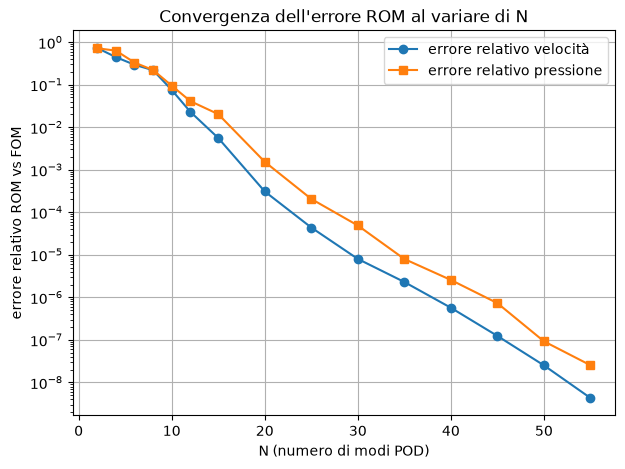

In [35]:
plt.figure(figsize=(7,5))
plt.semilogy(N_list, err_u_vs_N, '-o', label='errore relativo velocità')
plt.semilogy(N_list, err_p_vs_N, '-s', label='errore relativo pressione')
plt.xlabel("N (numero di modi POD)")
plt.ylabel("errore relativo ROM vs FOM")
plt.title("Convergenza dell'errore ROM al variare di N")
plt.legend()
plt.grid(True)
plt.show()

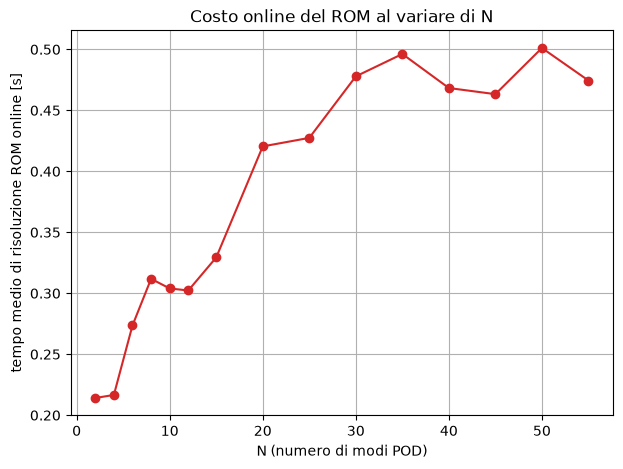

In [36]:
plt.figure(figsize=(7,5))
plt.plot(N_list, time_rom_vs_N, '-o', color='tab:red')
plt.xlabel("N (numero di modi POD)")
plt.ylabel("tempo medio di risoluzione ROM online [s]")
plt.title("Costo online del ROM al variare di N")
plt.grid(True)
plt.show()

### Statistica tempo per costruzione POD

In [37]:
snapshot_num = 100  # larghezza training set iniziale
tol = 1. - 1e-7   # qnt massima da spiegare con gli snapshot presi come base dello spazio ridotto
N_max = 30    # numero massimo di snapshots nella base dello spazio ridotto
n_iter = 5

mu0_range = [0.1, 10.0]   # dominio fornito da prof
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])
pod_build_times = []

np.random.seed(0)
for i in range(0, n_iter):
    start_cycle = time.perf_counter() 
    training_set_per_stat = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))

    snapshot_matrix_u = []  # sia u_x che u_y
    snapshot_matrix_s = [] ### supremizer snapshot
    snapshot_matrix_p = []
    
    print("Performing training...")
    
    it = 0
    for mu in training_set_per_stat:
    
      if it % 10 == 0:
          print("\tIterations", 2 * it, " /", training_set_per_stat.size)
      it = it + 1
    
      mu_0 = mu[0]
      mu_1 = mu[1]
    
      def pressure_strong_function(marker, x, y, z):  # definisco qui perché in generale potrebbe dipendere dai parametri
        return 0.0
        
      p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           pressure_mesh_dofs_info,
                                                                           pressure_dofs_data,
                                                                           pressure_reference_element_data,
                                                                           pressure_strong_function)
      def speed_x_strong_function(marker, x, y, z):
            return 0.0
        
      def speed_y_strong_function(marker, x, y, z):
            return 0.0
        
      u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                               mesh,
                                                                               mesh_geometric_data,
                                                                               speed_mesh_dofs_info,
                                                                               speed_dofs_data,
                                                                               speed_reference_element_data,
                                                                               speed_x_strong_function)
      u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                               mesh,
                                                                               mesh_geometric_data,
                                                                               speed_mesh_dofs_info,
                                                                               speed_dofs_data,
                                                                               speed_reference_element_data,
                                                                               speed_y_strong_function)
        
     
      def f_x_function(x, y, z):
            return - ((mu_1**3) * np.pi * np.pi * np.cos((mu_1**2)* np.pi * x) - (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) + (+mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y))
      def f_y_function(x, y, z):
            return - (-(mu_1**3) * np.pi * np.pi * np.cos((mu_1**2) * np.pi * y) + (mu_1**2) * np.pi * np.pi) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) + (-mu_1* np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y))
        
    
      J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
      
      f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_reference_element_data,
                                                                           f_x_function)
      f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_reference_element_data,
                                                                           f_y_function)
    
      f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante
        
      snapshot_solution, flag, num_iter = find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)  
        
      snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
      snapshot_matrix_u.append(np.copy(snapshot_u))
      
      snapshot_p = snapshot_solution[2 * speed_n_dofs:]
      snapshot_matrix_p.append(np.copy(snapshot_p))
    
      snapshot_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snapshot_p)
      snapshot_matrix_s.append(np.copy(snapshot_s)) 
    
    snapshot_matrix_u = np.array(snapshot_matrix_u)
    snapshot_matrix_s = np.array(snapshot_matrix_s)
    snapshot_matrix_p = np.array(snapshot_matrix_p)  
    
    print("Training performed")
    
    C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
    C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
    C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)
    
    N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
    N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
    N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)
    
    reduced_u_dof = N_u + N_s

    basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
    basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
    basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

    global_basis_function_matrix = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
    global_basis_function_matrix[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
    global_basis_function_matrix[0:basis_functions_u.shape[0], N_u : N_u + N_s] = basis_functions_s
    global_basis_function_matrix[basis_functions_u.shape[0]:, N_u + N_s:] = basis_functions_p
    print(global_basis_function_matrix.shape)
    
    global_basis_function_matrix_no_sup = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_p))
    global_basis_function_matrix_no_sup[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
    global_basis_function_matrix_no_sup[basis_functions_u.shape[0]:, N_u:] = basis_functions_p
    
    end_cycle = time.perf_counter()     # <-- timestamp finale del ciclo
    pod_build_times.append(end_cycle - start_cycle)
    print(f"Tempo ciclo {i+1}/{n_iter}: {pod_build_times[-1]:.3f} s")

print(f"\nTempo medio per ciclo: {np.mean(pod_build_times):.3f} s")
print(f"Deviazione standard: {np.std(pod_build_times):.3f} s")

Performing training...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Training performed
(6761, 69)
Tempo ciclo 1/5: 53.332 s
Performing training...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Training performed
(6761, 70)
Tempo ciclo 2/5: 56.429 s
Performing training...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Training performed
(6761, 69)
Tempo ciclo 3/5: 52.923 s
Performing training...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	It